# Model Long-Term Baseline Comparison

This notebook compares two model long-term baseline outputs for:

- runoff
- ET
- SWE
- soil moisture
- groundwater

For each variable it shows:

- overlaid time series
- Model A - Model B difference
- summary statistics (mean, bias, RMSE, correlation)

In [10]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.style.use('default')

In [14]:
# -----------------------------
# User configuration
# -----------------------------
MODEL_A_NAME = 'Model A'
MODEL_B_NAME = 'Model B'

MODEL_A_EXPERIMENT_DIR = Path('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260324_bigBuckt')
MODEL_B_EXPERIMENT_DIR = Path('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260319_bigBuckt')

# Optional explicit file paths. If None, notebook will auto-detect from the experiment directory.
MODEL_A_FILE = None
MODEL_B_FILE = None

# If None, do not apply clipping.
START_DATE = None  # Example: '2011-10-01'
END_DATE = None    # Example: '2020-09-30'

# Used to convert runoff flux to mm/day if runoff is in m/s.
RUNOFF_TO_MM_PER_DAY = 86400.0 * 1000.0

# ET flux to mm/day (for kg/m2/s or mm/s).
ET_TO_MM_PER_DAY = 86400.0

print(f'Model A experiment: {MODEL_A_EXPERIMENT_DIR}')
print(f'Model B experiment: {MODEL_B_EXPERIMENT_DIR}')
print(f'Model A file override: {MODEL_A_FILE}')
print(f'Model B file override: {MODEL_B_FILE}')

Model A experiment: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260324_bigBuckt
Model B experiment: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260319_bigBuckt
Model A file override: None
Model B file override: None


In [15]:
def _to_series(ds, candidates):
    for var in candidates:
        if var in ds:
            s = ds[var].squeeze().to_pandas()
            s.index = pd.to_datetime(s.index)
            if getattr(s.index, 'tz', None) is not None:
                s.index = s.index.tz_localize(None)
            return s, var
    return None, None


def detect_longterm_file(experiment_dir):
    experiment_dir = Path(experiment_dir)
    if not experiment_dir.exists():
        raise FileNotFoundError(f'Experiment directory not found: {experiment_dir}')

    candidates = [
        experiment_dir / 'ensemble' / 'results' / 'baseline_longterm' / 'longterm_baseline_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_longterm' / 'baseline_longterm_timestep.nc',
    ]

    for path in candidates:
        if path.exists():
            return path

    matches = sorted((experiment_dir / 'ensemble' / 'results').rglob('*longterm*_*timestep.nc'))
    if matches:
        return matches[0]

    matches = sorted((experiment_dir / 'ensemble' / 'results').rglob('*baseline*_*timestep.nc'))
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f'Could not auto-detect long-term baseline timestep file in {experiment_dir}'
    )


def clip_window(series, start, end):
    if series is None:
        return None
    s = series
    if start is not None:
        s = s.loc[pd.Timestamp(start):]
    if end is not None:
        s = s.loc[:pd.Timestamp(end)]
    return s


def align_pair(a, b):
    merged = pd.concat([a.rename('a'), b.rename('b')], axis=1).dropna()
    return merged['a'], merged['b']


def get_all_series(ds):
    out = {}

    # Runoff
    runoff, runoff_var = _to_series(ds, ['averageRoutedRunoff', 'averageInstantRunoff'])
    if runoff is not None:
        runoff = runoff * RUNOFF_TO_MM_PER_DAY
    out['runoff'] = {'series': runoff, 'source_var': runoff_var, 'units': 'mm/day'}

    # ET
    et, et_var = _to_series(ds, ['scalarTotalET', 'scalarLatHeatTotal'])
    if et_var == 'scalarTotalET' and et is not None:
        et = -et * ET_TO_MM_PER_DAY
    elif et_var == 'scalarLatHeatTotal' and et is not None:
        latent_heat_vap = 2.45e6
        et = -et * ET_TO_MM_PER_DAY / latent_heat_vap
    if et is not None:
        et = et.resample('D').mean()
    out['et'] = {'series': et, 'source_var': et_var, 'units': 'mm/day'}

    # SWE
    swe, swe_var = _to_series(ds, ['scalarSWE'])
    if swe is not None:
        swe = swe.resample('D').mean()
    out['swe'] = {'series': swe, 'source_var': swe_var, 'units': 'mm'}

    # Soil moisture = liquid + ice if available
    soil_liq, soil_liq_var = _to_series(ds, ['scalarTotalSoilLiq'])
    soil_ice, _ = _to_series(ds, ['scalarTotalSoilIce'])
    if soil_liq is not None:
        soil = soil_liq + (soil_ice if soil_ice is not None else 0.0)
        soil = soil.resample('D').mean()
    else:
        soil = None
    out['soil_moisture'] = {'series': soil, 'source_var': soil_liq_var, 'units': 'kg/m2'}

    # Groundwater: prefer storage, else baseflow proxy
    gw, gw_var = _to_series(ds, ['scalarAquiferStorage_mean', 'scalarAquiferBaseflow', 'scalarSoilBaseflow'])
    if gw is not None:
        gw = gw.resample('D').mean()
    out['groundwater'] = {'series': gw, 'source_var': gw_var, 'units': 'model units'}

    return out


def describe_coverage(name, packed):
    s = packed['series']
    var = packed['source_var']
    if s is None or len(s) == 0:
        return f'{name:14s} | var={var} | no data'
    return f"{name:14s} | var={var} | {s.index.min().date()} to {s.index.max().date()} | n={len(s)}"


model_a_file = Path(MODEL_A_FILE) if MODEL_A_FILE else detect_longterm_file(MODEL_A_EXPERIMENT_DIR)
model_b_file = Path(MODEL_B_FILE) if MODEL_B_FILE else detect_longterm_file(MODEL_B_EXPERIMENT_DIR)

if not model_a_file.exists():
    raise FileNotFoundError(f'Model A file not found: {model_a_file}')
if not model_b_file.exists():
    raise FileNotFoundError(f'Model B file not found: {model_b_file}')

ds_a = xr.open_dataset(model_a_file)
ds_b = xr.open_dataset(model_b_file)

series_a = get_all_series(ds_a)
series_b = get_all_series(ds_b)

print(f'Using Model A file: {model_a_file}')
print(f'Using Model B file: {model_b_file}')
print('Loaded variables and coverage:')
for key in ['runoff', 'et', 'swe', 'soil_moisture', 'groundwater']:
    print(f'  {MODEL_A_NAME}: {describe_coverage(key, series_a[key])}')
    print(f'  {MODEL_B_NAME}: {describe_coverage(key, series_b[key])}')

if series_a['runoff']['series'] is not None and series_b['runoff']['series'] is not None:
    a0, b0 = align_pair(series_a['runoff']['series'], series_b['runoff']['series'])
    print(f'  Runoff overlap points: {len(a0)}')

Using Model A file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260324_bigBuckt/ensemble/results/baseline_longterm/baseline_longterm_timestep.nc
Using Model B file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260319_bigBuckt/ensemble/results/baseline_longterm/baseline_longterm_timestep.nc
Loaded variables and coverage:
  Model A: runoff         | var=averageRoutedRunoff | 2000-10-01 to 2021-09-30 | n=184057
  Model B: runoff         | var=averageRoutedRunoff | 2000-10-01 to 2021-09-30 | n=184057
  Model A: et             | var=scalarTotalET | 2000-10-01 to 2021-09-30 | n=7670
  Model B: et             | var=scalarTotalET | 2000-10-01 to 2021-09-30 | n=7670
  Model A: swe            | var=scalarSWE | 2000-10-01 to 2021-09-30 | n=7670
  Model B: swe            | var=scalarSWE | 2000-10-01 to 2021-09-30 | n=7670
  Model A: soil_moisture  | var=scalarTotalSoilLiq | 2000-10-01 to 2021-09-30 | n=7670
  Model B: soil_moisture  | var=sc

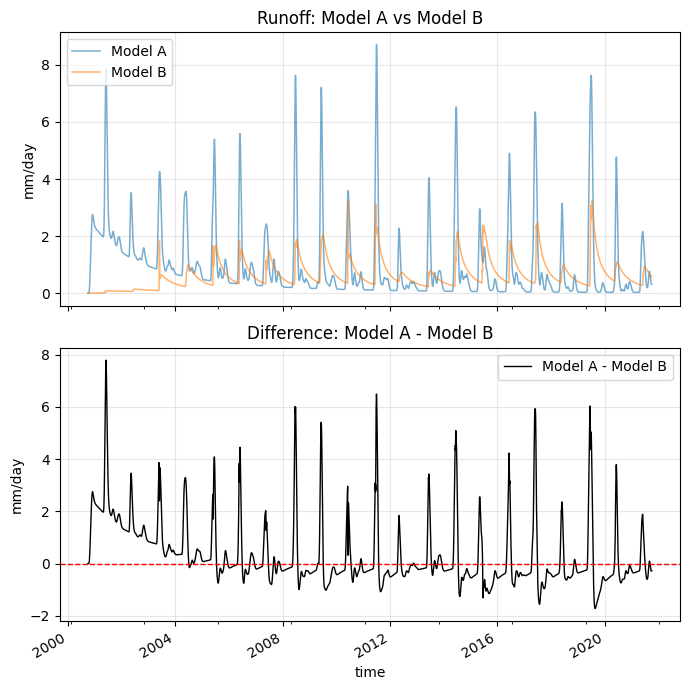

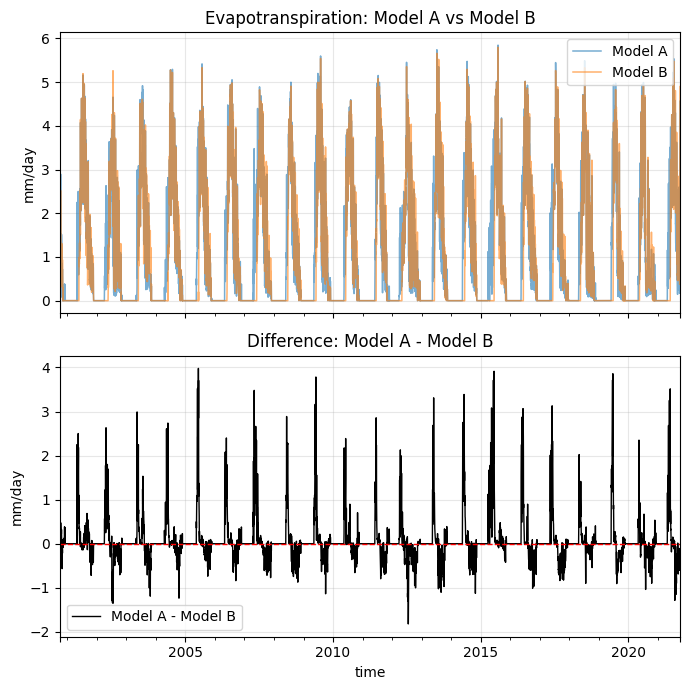

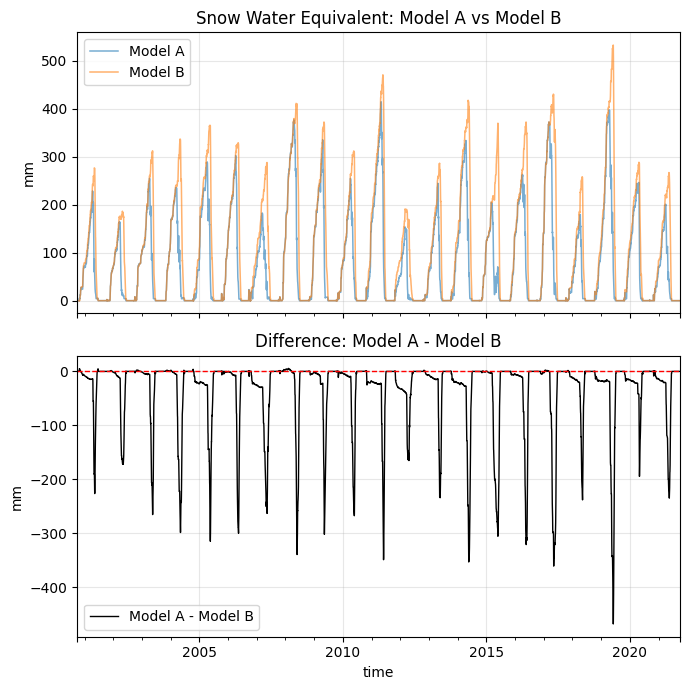

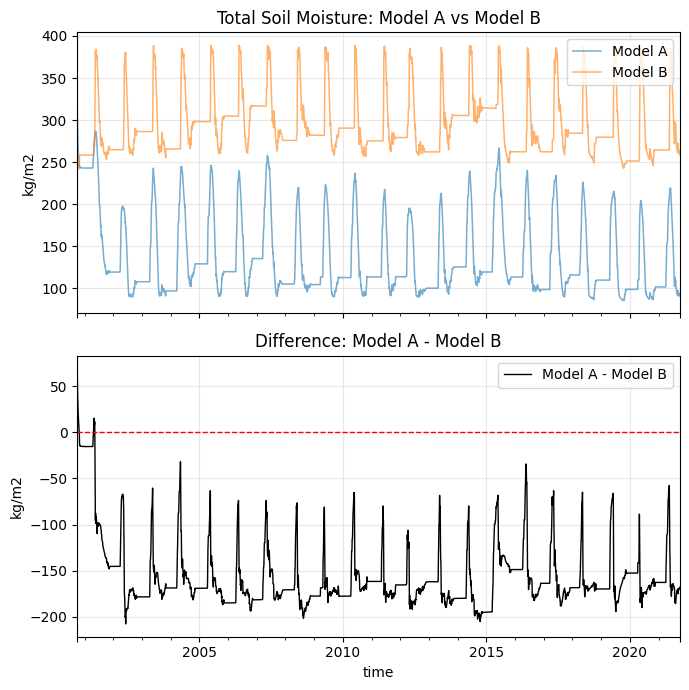

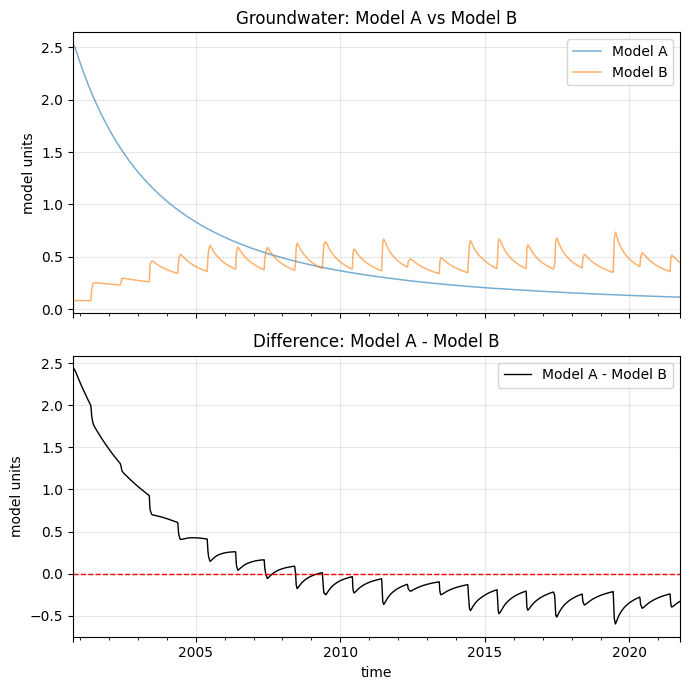

,variable,units,n_points,mean_Model A,mean_Model B,mean_diff_A_minus_B,rmse_A_vs_B,corr
0,runoff,mm/day,184057,1.006342,0.655899,0.350443,1.378293,0.247874
1,et,mm/day,7670,0.916804,0.852873,0.063930,0.511266,0.922475
2,swe,mm,7670,74.416930,108.729714,-34.312784,79.258326,0.815956
3,soil_moisture,kg/m2,7670,136.238037,292.207258,-155.969221,160.454926,0.614440
4,groundwater,model units,7670,0.543480,0.431163,0.112316,0.632008,-0.715225


In [16]:
def compare_and_plot(var_key, title):
    a = series_a[var_key]['series']
    b = series_b[var_key]['series']
    units = series_a[var_key]['units']

    if a is None or b is None:
        print(f'Skipping {var_key}: missing in one or both models')
        return None

    a = clip_window(a, START_DATE, END_DATE)
    b = clip_window(b, START_DATE, END_DATE)

    a_aligned, b_aligned = align_pair(a, b)
    if len(a_aligned) == 0:
        print(f'Skipping {var_key}: no overlapping timetestamps after clipping')
        return None

    diff = a_aligned - b_aligned

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

    ax = axes[0]
    a_aligned.plot(ax=ax, linewidth=1.1, label=MODEL_A_NAME, alpha=0.6)
    b_aligned.plot(ax=ax, linewidth=1.1, label=MODEL_B_NAME, alpha=0.6)
    ax.set_title(f'{title}: {MODEL_A_NAME} vs {MODEL_B_NAME}')
    ax.set_ylabel(units)
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    diff.plot(ax=ax, color='black', linewidth=1.0, label=f'{MODEL_A_NAME} - {MODEL_B_NAME}')
    ax.axhline(0.0, color='red', linestyle='--', linewidth=1.0)
    ax.set_title(f'Difference: {MODEL_A_NAME} - {MODEL_B_NAME}')
    ax.set_ylabel(units)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    stats = {
        'variable': var_key,
        'units': units,
        'n_points': int(len(diff)),
        f'mean_{MODEL_A_NAME}': float(a_aligned.mean()),
        f'mean_{MODEL_B_NAME}': float(b_aligned.mean()),
        'mean_diff_A_minus_B': float(diff.mean()),
        'rmse_A_vs_B': float(np.sqrt(np.mean(diff**2))),
        'corr': float(a_aligned.corr(b_aligned)),
    }
    return stats


summary = []
summary.append(compare_and_plot('runoff', 'Runoff'))
summary.append(compare_and_plot('et', 'Evapotranspiration'))
summary.append(compare_and_plot('swe', 'Snow Water Equivalent'))
summary.append(compare_and_plot('soil_moisture', 'Total Soil Moisture'))
summary.append(compare_and_plot('groundwater', 'Groundwater'))

summary = [s for s in summary if s is not None]
summary_df = pd.DataFrame(summary)
summary_df

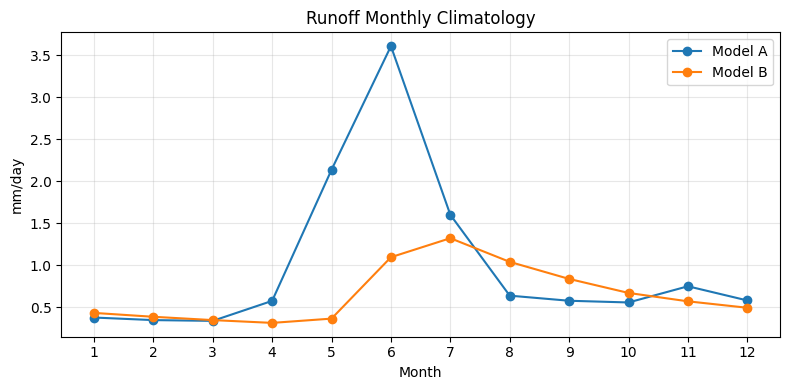

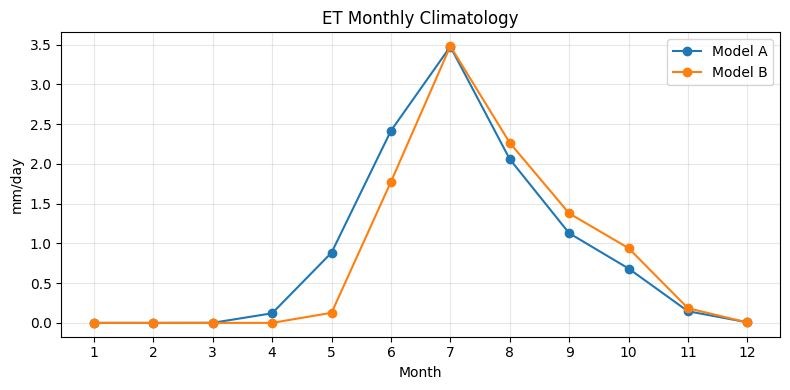

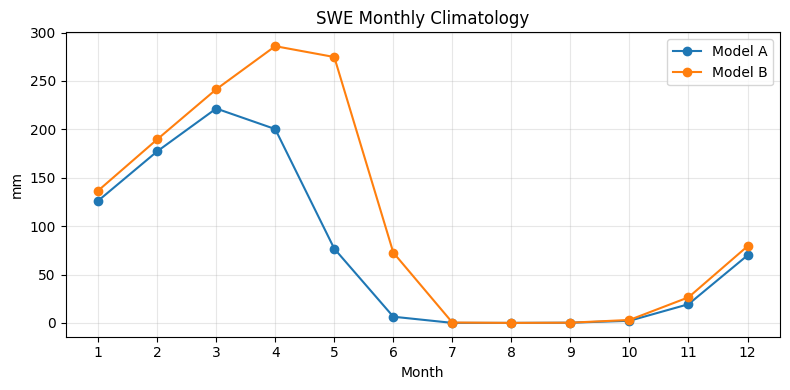

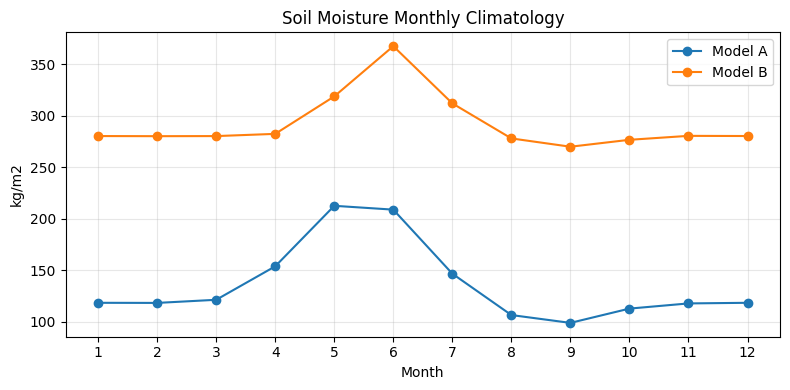

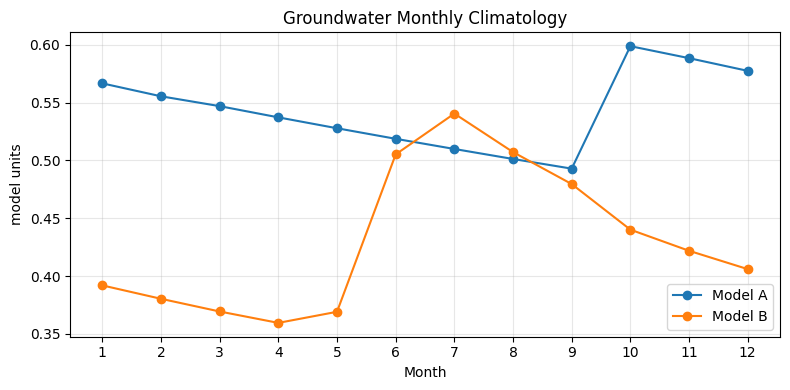

In [17]:
# Optional monthly climatology comparison

def plot_monthly_climatology(var_key, title):
    a = series_a[var_key]['series']
    b = series_b[var_key]['series']

    if a is None or b is None:
        return

    a = clip_window(a, START_DATE, END_DATE)
    b = clip_window(b, START_DATE, END_DATE)
    a_aligned, b_aligned = align_pair(a, b)
    if len(a_aligned) == 0:
        return

    a_month = a_aligned.groupby(a_aligned.index.month).mean()
    b_month = b_aligned.groupby(b_aligned.index.month).mean()

    plt.figure(figsize=(8, 4))
    plt.plot(a_month.index, a_month.values, marker='o', label=MODEL_A_NAME)
    plt.plot(b_month.index, b_month.values, marker='o', label=MODEL_B_NAME)
    plt.xticks(range(1, 13))
    plt.xlabel('Month')
    plt.ylabel(series_a[var_key]['units'])
    plt.title(f'{title} Monthly Climatology')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_monthly_climatology('runoff', 'Runoff')
plot_monthly_climatology('et', 'ET')
plot_monthly_climatology('swe', 'SWE')
plot_monthly_climatology('soil_moisture', 'Soil Moisture')
plot_monthly_climatology('groundwater', 'Groundwater')